<a href="https://colab.research.google.com/github/SongXP111/Makemore/blob/main/makemore_part2_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [679]:
# Prepare necessary files
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-04-13 03:41:47--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.19’

names.txt.19        100%[===================>] 222.80K  --.-KB/s    in 0.08s   

2026-04-13 03:41:47 (2.63 MB/s) - ‘names.txt.19’ saved [228145/228145]



In [680]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [681]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [682]:
len(words)

32033

In [683]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [684]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [685]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [686]:
# Build the dataset and split into training, dev/validation, and testing splits

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [687]:
# Embedding layer: lookup table
C = torch.randn((27, 2))
C.shape

torch.Size([27, 2])

In [688]:
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# which is equal to
# c[5]

# Batch embedding lookup (output of embedding layer)
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [689]:
# Hidden layer

In [690]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [691]:
# 1. emb.view(-1, 6): Flatten (3, 2) into 6
# 2. @ W1 + b1: Use matrix multiplication to apply weights and add bias to 100
# neurons
# 3. torch.tanh(): Put all the number between [-1, 1] (Activation function)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [692]:
h

tensor([[ 0.8145, -0.4555, -0.9800,  ..., -0.4874,  0.8303, -0.8901],
        [ 0.7881,  0.0721, -0.7021,  ...,  0.0206,  0.7123, -0.9045],
        [-0.9921,  0.9740, -0.9467,  ...,  0.6514,  0.7625, -0.9905],
        ...,
        [ 0.8345,  0.0295, -0.9744,  ...,  0.9995, -0.9451, -0.1568],
        [-0.1294,  0.1541, -0.9995,  ...,  0.9757, -0.9326, -0.4748],
        [ 0.9866,  0.7272,  0.9974,  ...,  0.9997, -0.9888,  0.6097]])

In [693]:
h.shape

torch.Size([228146, 100])

In [694]:
# Output layer

In [695]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [696]:
logits = h @ W2 + b2

In [697]:
logits.shape

torch.Size([228146, 27])

In [698]:
counts = logits.exp() # 指数化，把结果变为正数

In [699]:
prob = counts / counts.sum(1, keepdims=True) # 归一化，把数字压缩到[0, 1]之间

In [700]:
prob.shape

torch.Size([228146, 27])

In [701]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [702]:
loss = -prob[torch.arange(228146), Y].log().mean()
loss

tensor(18.4082)

In [703]:
# Put things together

In [704]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [705]:
# Parameter Initialization
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [706]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [707]:
for p in parameters:
  p.requires_grad = True

In [708]:
lre = torch.linspace(-3, 0, 1000) # learning rate exponent
lrs = 10 ** lre # actual learning rates
# lrs

In [709]:
# Track performance of different learning rates
lri = []
lossi = []
stepi = []

In [722]:
# Training loop

for i in range(50000):
  # mini-batch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # Forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  # print(loss.item())

  # Backward pass
  for p in parameters:
    p.grad = None # 梯度清零
  loss.backward() # 自动求导

  # Update
  # lr = lrs[i]
  lr = 0.01 # it is good based on the stats
  for p in parameters:
    p.data += -lr * p.grad

  # Track stats
  # lri.append(lre[i])
  lossi.append(loss.log10().item())
  stepi.append(i)


# print(loss.item())

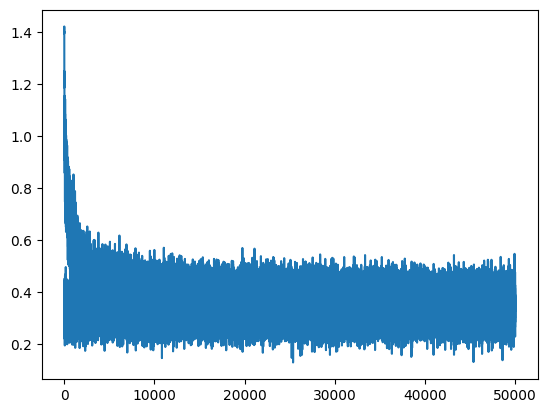

In [723]:
plt.plot(stepi, lossi)

In [724]:
# Training Result
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1751, grad_fn=<NllLossBackward0>)

In [725]:
# Dev/Validation
# Purpose: Hyperparameter tuning
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1983, grad_fn=<NllLossBackward0>)

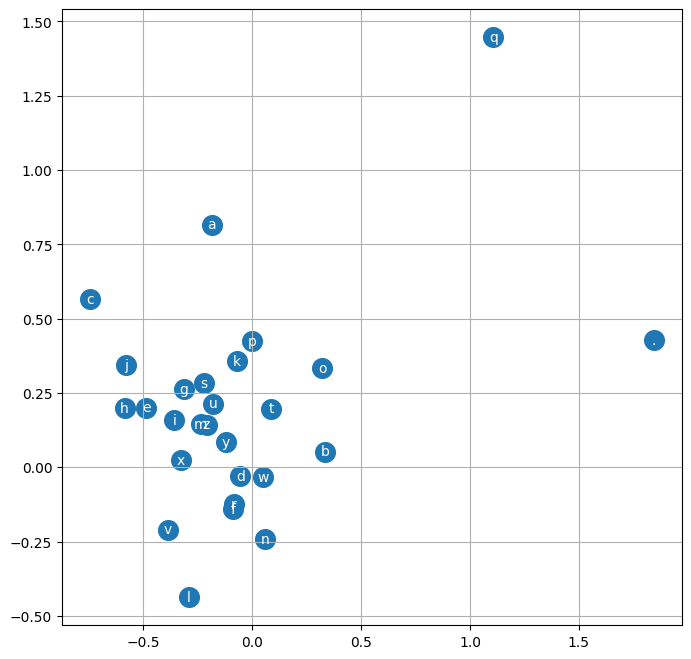

In [726]:
# Visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [727]:
# Training split, dev/validation split, test split
# 80%, 10%, 10%

In [728]:
# Results
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [729]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlah.
amille.
khi.
myli.
taty.
halayane.
mahnender.
sara.
kaqui.
nellara.
chaiiv.
kaleigh.
ham.
pris.
quinn.
salin.
alian.
quinathoniearynix.
kaelidgsabee.
demi.
